In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import torch

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")

cuda available
gpu ready


In [2]:
PATH_PLAYLIST = Path("../data/playlist")
PATH_CHUNKS = PATH_PLAYLIST / "chunks/"
PATH_CHUNKS_MANIFEST = PATH_CHUNKS / "manifest.json"
PATH_TRAIN_VOCAB = PATH_PLAYLIST / "training_vocab.parquet"

# Data loading

In [3]:
import json
    
def fetch_chunk(n: int):
    with open(PATH_CHUNKS_MANIFEST) as f:
        chunks_manifest = json.load(f)
    if n < 0 or n >= chunks_manifest["total_chunks"]:
        raise ValueError(f"Chunks are number between 0 and {chunks_manifest["total_chunks"]}")
    return pd.read_parquet(f"{PATH_CHUNKS}/chunk_{n:06d}.parquet", columns=["playlist_rowid", "track_rowid"])

_playlist_tracks = fetch_chunk(0)
print(f"Chunk 0 — raw")
print(f"  Interactions : {len(_playlist_tracks):>10,}")
print(f"  Playlists    : {_playlist_tracks['playlist_rowid'].nunique():>10,}")
print(f"  Tracks       : {_playlist_tracks['track_rowid'].nunique():>10,}")

Chunk 0 — raw
  Interactions : 20,369,645
  Playlists    :     99,524
  Tracks       :  4,750,816


# Preparing track vocab

In [4]:
CMIN = 150
PROD = False

vocab = pd.read_parquet(PATH_TRAIN_VOCAB)
vocab = vocab[
    vocab["playlist_count"] >= CMIN
].reset_index(drop=True)
# this will allow experimenting on a single chunk with small VRAM
if not PROD:
    vocab = vocab[
        vocab["track_rowid"].isin(_playlist_tracks["track_rowid"].unique())
    ].reset_index(drop=True)
# when CMIN > 2, the track_id ceases being contiguous. we fix this with the next line
vocab["track_id"] = vocab.index.astype("int32")
vocab

,track_rowid,track_id,playlist_count
0,1,0,52538
1,4,1,470
2,5,2,416
3,7,3,408
4,8,4,3675
...,...,...,...
946638,160893835,946638,342
946639,160898428,946639,545
946640,160898519,946640,199
946641,160898592,946641,347


## Filtering and mapping interactions

In [5]:
playlist_tracks = (
    _playlist_tracks.join(
        vocab.set_index("track_rowid")["track_id"],
        on="track_rowid", how="inner",
    )
        .astype({"track_id": int})
        .reset_index(drop=True)
)
n_dropped = len(_playlist_tracks) - len(playlist_tracks)
print(f"After OOV filtering (CMIN={CMIN}, {'PROD' if PROD else 'single-chunk'})")
print(f"  Interactions : {len(playlist_tracks):>10,}  ({n_dropped:,} dropped, {100*n_dropped/len(_playlist_tracks):.1f}%)")
print(f"  Playlists    : {playlist_tracks['playlist_rowid'].nunique():>10,}")
print(f"  Tracks       : {playlist_tracks['track_rowid'].nunique():>10,}")

After OOV filtering (CMIN=150, single-chunk)
  Interactions : 14,382,375  (5,987,270 dropped, 29.4%)
  Playlists    :     96,579
  Tracks       :    946,643


In [6]:
vc = playlist_tracks["track_rowid"].value_counts()
print(vc.describe())
print()
print(vc.value_counts().head(10).rename("n_tracks"))  # how many tracks appear exactly N times

count    946643.000000
mean         15.193029
std          77.528130
min           1.000000
25%           2.000000
50%           5.000000
75%          10.000000
max       19236.000000
Name: count, dtype: float64

count
1     138781
2     125755
3     108389
4      89126
5      70679
6      56051
7      44870
8      35553
9      29126
10     23983
Name: n_tracks, dtype: int64


# Subsampling

In [7]:
def subsample(pt: pd.DataFrame, vocab: pd.DataFrame, q: float = 0.99) -> pd.DataFrame:
    """Discard frequent track occurrences using word2vec-style subsampling.

    The threshold t is set to the q-th quantile of the global frequency
    distribution, so that exactly (1 - q) of tracks by count are eligible
    for subsampling. Track i is then kept with probability:

        p(keep | i) = min(1, sqrt(t / freq[i]))

    Tracks with freq[i] <= t are always kept (p = 1). Tracks above the
    threshold are kept with probability proportional to sqrt(t / freq[i]),
    dampening the dominance of the most ubiquitous tracks without discarding
    them entirely.

    Args:
        pt:    interaction DataFrame with a track_id column (RangeIndex-aligned to vocab).
        vocab: vocab DataFrame with a playlist_count column (RangeIndex = track_id).
        q:     quantile threshold — fraction of tracks guaranteed to be kept.
               Default 0.99: only the top 1% most frequent tracks are subsampled.
    """
    freq = vocab["playlist_count"] / vocab["playlist_count"].sum()
    t = float(freq.quantile(q))
    keep_prob = np.minimum(1.0, np.sqrt(t / freq))
    p = pt["track_id"].map(keep_prob).values
    mask = np.random.rand(len(pt)) < p
    return pt[mask].reset_index(drop=True)


playlist_tracks = subsample(playlist_tracks, vocab)
playlist_tracks

,playlist_rowid,track_rowid,track_id
0,3,1,0
1,3,4,1
2,3,8,4
3,3,9,5
4,3,10,6
...,...,...,...
12799435,104520,71358,42283
12799436,104520,71062,42128
12799437,104520,14815,9969
12799438,104520,14789,9948


In [8]:
def build_weights(vocab: pd.DataFrame) -> torch.Tensor:
    """Build a normalised negative-sampling weight tensor aligned to track_id order.

    Weights are proportional to freq^0.75 (word2vec unigram smoothing): frequent
    tracks are sampled more often as negatives, but the exponent dampens the
    dominance of the very top tracks.

    The returned tensor has shape (vocab_size,) where position i is the sampling
    weight for track_id=i, ready for torch.multinomial.
    """
    freq = vocab["playlist_count"] / vocab["playlist_count"].sum()
    weights = torch.tensor((freq ** 0.75).sort_index().to_numpy(), dtype=torch.float32)
    return weights / weights.sum()

weights = build_weights(vocab)
weights

tensor([2.1659e-05, 6.3001e-07, 5.7490e-07,  ..., 3.3068e-07, 5.0179e-07,
        3.9240e-07])

In [9]:
def flatten(pt: pd.DataFrame) -> dict[int, list[int]]:
    """Group interactions into a playlist → [track_ids] dictionary."""
    return pt.groupby("playlist_rowid")["track_id"].apply(list).to_dict()

# Model

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Word2Vec(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int):
        super().__init__()
        self.embeddings_in = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        self.embeddings_out = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        nn.init.uniform_(self.embeddings_in.weight, -0.5 / embed_dim, 0.5 / embed_dim)
        nn.init.uniform_(self.embeddings_out.weight, -0.5 / embed_dim, 0.5 / embed_dim)

    def forward(
        self, center: torch.Tensor, context: torch.Tensor, negatives: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            pos_score: (batch,) dot product between center and context embeddings
            neg_score: (batch, K) dot products between center and each negative embedding
        """
        ecenter = self.embeddings_in(center)
        econtext = self.embeddings_out(context)
        enegative = self.embeddings_out(negatives)

        pos_score = (ecenter * econtext).sum(dim=1)
        neg_score = torch.bmm(enegative, ecenter.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score

    @property
    def track_embeddings(self) -> torch.Tensor:
        return self.embeddings_in.weight.detach()

# Loss

In [11]:
def skipgram_loss(
    pos_score: torch.Tensor, neg_score: torch.Tensor
) -> torch.Tensor:
    """Negative-sampling loss for skip-gram Word2Vec."""
    pos_loss = F.logsigmoid(pos_score)
    neg_loss = F.logsigmoid(-neg_score).sum(dim=1)
    return -(pos_loss + neg_loss).mean()

# Dataset

In [12]:
def playlist_pairs(playlist: list[int], W: int) -> tuple[torch.Tensor, torch.Tensor]:
    t = torch.tensor(playlist, dtype=torch.long)
    W = min(2 * W, len(playlist) - 1)
    offsets = [k for k in range(-W // 2, W // 2 + 1) if k]
    centers = t.repeat(len(offsets))
    contexts = torch.cat([torch.roll(t, -k) for k in offsets])
    return torch.stack((centers, contexts))



def pairs(playlist, W):
    c, x = playlist_pairs(playlist, W)
    return list(zip(c.tolist(), x.tolist()))


assert pairs([1,2,3], 1) == [(1,3),(2,1),(3,2),(1,2),(2,3),(3,1)]
assert pairs([1,2,3,4], 1) == [(1,4),(2,1),(3,2),(4,3),(1,2),(2,3),(3,4),(4,1)]
assert pairs([1,2,3,4,5], 2) == [(1,4),(2,5),(3,1),(4,2),(5,3),(1,5),(2,1),(3,2),(4,3),(5,4),(1,2),(2,3),(3,4),(4,5),(5,1),(1,3),(2,4),(3,5),(4,1),(5,2)]
assert pairs([1,2], 5) == [(1, 2), (2, 1)]
assert pairs([1,2,3,4], 100) == pairs([1,2,3,4], 2)

In [13]:
np.random.seed(0)

playlist_unique = playlist_tracks["playlist_rowid"].unique()
np.random.shuffle(playlist_unique)
playlist_train = playlist_unique[:int(0.9 * len(playlist_unique))]
train_mask = playlist_tracks["playlist_rowid"].isin(playlist_train)
train_df = playlist_tracks[train_mask].reset_index(drop=True)
valid_df = playlist_tracks[~train_mask].reset_index(drop=True)
print(f"train amounts to {100 * len(train_df) / len(playlist_tracks):.1f} % of the dataset")

train amounts to 90.6 % of the dataset


In [14]:
from typing import Callable

def get_nsampler(weights_gpu: torch.Tensor, K: int) -> Callable:
    return lambda n: torch.multinomial(weights_gpu, n * K, replacement=True).view(-1, K)


def precompute_pairs(playlists: pd.DataFrame, W: int) -> torch.Tensor:
    tensors = [playlist_pairs(p, W) for p in flatten(playlists).values() if len(p) >= 2]
    return torch.cat(tensors, dim=1)

# Training

In [15]:
EMBED_DIM = 128
NEPOCHS = 10
LR = 1e-3
BATCH_SIZE = 64_000
SEED = 0
W, K = 5, 10

In [16]:
vocab_size = len(vocab)
B, D = BATCH_SIZE, EMBED_DIM
MiB = 1 / 1_048_576
GiB = 1 / 1_073_741_824
BYTES_IN_32BIT = 4

embed    = 2 * vocab_size * D * BYTES_IN_32BIT    # both embedding tables (in + out)
optim    = 2 * embed                 # SparseAdam: exp_avg + exp_avg_sq
                                     # initialised as dense tensors — same size as embed
weights_ = vocab_size * BYTES_IN_32BIT            # neg-sampling weights on GPU
act_fwd  = (2 + K) * B * D * BYTES_IN_32BIT       # ecenter (B×D) + econtext (B×D) + enegative (B×K×D)
act_bwd  = act_fwd                   # sparse grads upper bound ≈ forward activations
total    = embed + optim + weights_ + act_fwd + act_bwd

print(f"Vocab size          : {vocab_size:>10,}  ({'PROD' if PROD else 'single-chunk'})")
print(f"Config              : EMBED_DIM={D}  BATCH_SIZE={B:,}  W={W}  K={K}")
print()
print(f"Embedding tables    : {embed    * GiB:>6.2f} GB  (2 tables × {vocab_size:,} × {D} × fp32)")
print(f"Optimizer state     : {optim    * GiB:>6.2f} GB  (SparseAdam exp_avg + exp_avg_sq, dense after warmup)")
print(f"Neg. sample weights : {weights_ * MiB:>6.1f} MB")
print(f"Activations fwd     : {act_fwd  * MiB:>6.1f} MB  ({2+K} tensors × {B:,} × {D})")
print(f"Activations bwd     : {act_bwd  * MiB:>6.1f} MB  (sparse grad upper bound)")
print()
print(f"Total estimate      : {total    * GiB:>6.2f} GB")
print()
if torch.cuda.is_available():
    vram_total = torch.cuda.get_device_properties(0).total_memory
    vram_free, _ = torch.cuda.mem_get_info()
    headroom = vram_free - total
    flag = "OK" if headroom > 0 else "OOM RISK"
    print(f"GPU                 : {torch.cuda.get_device_properties(0).name}")
    print(f"VRAM total          : {vram_total * GiB:>6.2f} GB")
    print(f"VRAM free now       : {vram_free  * GiB:>6.2f} GB")
    print(f"Headroom            : {headroom   * GiB:>+6.2f} GB  [{flag}]")

Vocab size          :    946,643  (single-chunk)
Config              : EMBED_DIM=128  BATCH_SIZE=64,000  W=5  K=10

Embedding tables    :   0.90 GB  (2 tables × 946,643 × 128 × fp32)
Optimizer state     :   1.81 GB  (SparseAdam exp_avg + exp_avg_sq, dense after warmup)
Neg. sample weights :    3.6 MB
Activations fwd     :  375.0 MB  (12 tensors × 64,000 × 128)
Activations bwd     :  375.0 MB  (sparse grad upper bound)

Total estimate      :   3.44 GB

GPU                 : NVIDIA GeForce RTX 2060
VRAM total          :   5.79 GB
VRAM free now       :   5.19 GB
Headroom            :  +1.75 GB  [OK]


In [17]:
train = precompute_pairs(train_df, W).pin_memory()
valid = precompute_pairs(valid_df, W).pin_memory()

In [18]:
import time
from torch.optim import SparseAdam
from torch.optim.lr_scheduler import ReduceLROnPlateau


device = torch.device("cuda")

weights_gpu = weights.to(device)
neg_sample = get_nsampler(weights_gpu, K)
model = Word2Vec(vocab_size=len(vocab), embed_dim=EMBED_DIM)
model = model.to(device)
optimizer = SparseAdam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

history = {"train": [], "valid": [], "lr": []}
best_valid_loss = float("inf")
best_state = None
best_epoch = -1

for epoch in range(NEPOCHS):
    t0 = time.perf_counter()
    torch.manual_seed(SEED + epoch)
    perm = torch.randperm(train.shape[1])
    centers, contexts = train
    centers_s, contexts_s = centers[perm], contexts[perm]

    model.train()
    nt, tloss_epoch = 0, 0.
    for nt, offset in enumerate(range(0, len(centers_s), BATCH_SIZE)):
        c = centers_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
        x = contexts_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
        n = neg_sample(len(c))

        optimizer.zero_grad()
        loss = skipgram_loss(*model(c, x, n))
        loss.backward()
        optimizer.step()
        tloss_epoch += loss.item()

    t1 = time.perf_counter()
    perm = torch.randperm(valid.shape[1])
    centers, contexts = valid
    centers_s, contexts_s = centers[perm], contexts[perm]

    model.eval()
    nv, vloss_epoch = 0, 0.
    with torch.no_grad():
        for nv, offset in enumerate(range(0, len(centers_s), BATCH_SIZE)):
            c = centers_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
            x = contexts_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
            n = neg_sample(len(c))
            vloss_epoch += skipgram_loss(*model(c, x, n)).item()

    t2 = time.perf_counter()

    train_loss = tloss_epoch / (nt + 1)
    valid_loss = vloss_epoch / (nv + 1)
    lr = optimizer.param_groups[0]["lr"]
    history["train"].append(train_loss)
    history["valid"].append(valid_loss)
    history["lr"].append(lr)

    is_best = valid_loss < best_valid_loss
    if is_best:
        best_valid_loss = valid_loss
        best_epoch = epoch + 1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    scheduler.step(valid_loss)

    w = len(str(NEPOCHS))
    print(
        f"epoch {epoch+1:{w}}/{NEPOCHS}"
        f"  │  train {train_loss:.4f}"
        f"  valid {valid_loss:.4f}"
        f"  │  lr {lr:.2e}"
        f"  │  {t2-t0:.0f}s  (train {t1-t0:.0f}s  valid {t2-t1:.0f}s)"
        + ("  *" if is_best else "")
    )

model.load_state_dict(best_state)
print(f"\nRestored best model from epoch {best_epoch}  (valid {best_valid_loss:.4f})")

epoch  1/10  │  train 3.6875  valid 2.7406  │  lr 1.00e-03  │  95s  (train 94s  valid 2s)  *
epoch  2/10  │  train 2.2721  valid 2.2277  │  lr 1.00e-03  │  95s  (train 93s  valid 2s)  *
epoch  3/10  │  train 1.8727  valid 1.9964  │  lr 1.00e-03  │  95s  (train 93s  valid 2s)  *
epoch  4/10  │  train 1.6471  valid 1.8706  │  lr 1.00e-03  │  95s  (train 93s  valid 2s)  *
epoch  5/10  │  train 1.5034  valid 1.7978  │  lr 1.00e-03  │  95s  (train 94s  valid 2s)  *
epoch  6/10  │  train 1.4038  valid 1.7559  │  lr 1.00e-03  │  95s  (train 93s  valid 2s)  *
epoch  7/10  │  train 1.3299  valid 1.7330  │  lr 1.00e-03  │  95s  (train 93s  valid 2s)  *
epoch  8/10  │  train 1.2719  valid 1.7225  │  lr 1.00e-03  │  95s  (train 94s  valid 2s)  *
epoch  9/10  │  train 1.2239  valid 1.7206  │  lr 1.00e-03  │  95s  (train 93s  valid 2s)  *
epoch 10/10  │  train 1.1830  valid 1.7237  │  lr 1.00e-03  │  95s  (train 93s  valid 2s)

Restored best model from epoch 9  (valid 1.7206)


### Recap

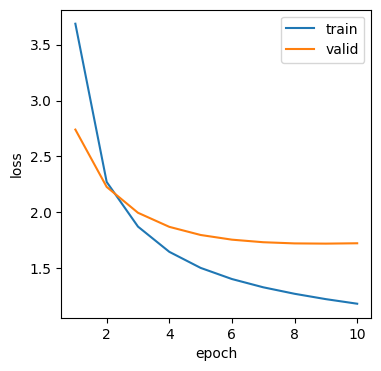

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
epochs = range(1, len(history["train"]) + 1)
ax.plot(epochs, history["train"], label="train")
ax.plot(epochs, history["valid"], label="valid")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
plt.show()

# Qualitative checks

In [20]:
# Load track lookup, keep only columns we need, inner-join with vocab
lookup = pd.read_parquet(
    "../data/playlist/track_lookup.parquet",
    columns=["track_rowid", "track_name", "artist_name", "track_popularity"],
)
lookup = lookup.merge(vocab, on="track_rowid", how="inner")
print(f"{len(lookup):,} tracks in lookup (should match vocab size {len(vocab):,})")
lookup.head()

946,643 tracks in lookup (should match vocab size 946,643)


,track_rowid,track_name,artist_name,track_popularity,track_id,playlist_count
0,1,The Giver,Chappell Roan,89,0,52538
1,4,Crash,NOTD,56,1,470
2,5,I Just Missed A Call,NOTD,51,2,416
3,7,WIFI,NOTD,55,3,408
4,8,SMOKE THE PAIN AWAY,Calvin Harris,75,4,3675


In [21]:
# L2-normalise embeddings once — cosine sim becomes a simple matmul
emb = model.track_embeddings.to(device)
emb_norm = emb / emb.norm(dim=1, keepdim=True)


def find_neighbours(query: str, k: int = 10, diverse: bool = True) -> pd.DataFrame:
    """Find top-k nearest neighbours by cosine similarity.

    `query` is matched case-insensitively against track_name. If multiple tracks
    match, the most popular one is used.
    If `diverse=True`, at most one track per artist is returned.
    """
    matches = lookup[lookup["track_name"].str.contains(query, case=False, na=False)]
    if matches.empty:
        print(f"No tracks matching '{query}'")
        return pd.DataFrame()

    row = matches.sort_values("track_popularity", ascending=False).iloc[0]
    tid = row["track_id"]
    print(f"Query: {row['track_name']} — {row['artist_name']}  (pop {row['track_popularity']})")

    sims = (emb_norm[tid] @ emb_norm.T).cpu().numpy()

    candidates = lookup.copy()
    candidates["similarity"] = sims[candidates["track_id"].values]
    candidates = candidates[candidates["track_id"] != tid]
    candidates = candidates.sort_values("similarity", ascending=False)
    if diverse:
        candidates = candidates.drop_duplicates(subset="artist_name")
    return candidates.head(k)[["track_name", "artist_name", "track_popularity", "similarity"]]

In [22]:
queries = [
    "Holland, 1945",
    "when you sleep",
    "Interzone",
    "About A Girl",
    "Battery",
    "Xtal",
    "Altibzz",
    "N.Y. State of Mind",
    "Mathematics",
    "Nuthin' But A 'G' Thang",
    "Figaro",
    "Bela Lugosi's Dead",
    "Just Like Heaven",
    "Once in a Lifetime",
    "Dunkelheit",
    "Valvonauta",
]

for q in queries:
    display(find_neighbours(q))
    print()

Query: Holland, 1945 — Neutral Milk Hotel  (pop 59)


,track_name,artist_name,track_popularity,similarity
401470,Two-Headed Boy,Neutral Milk Hotel,55,0.898447
558435,Knot Comes Loose,My Morning Jacket,32,0.808614
616106,Hideaway,The Olivia Tremor Control,26,0.794707
898961,Ball of the Dead Rat,The Teeth,0,0.788083
401449,Cut Your Hair,Pavement,56,0.786788
340774,(Joe Gets Kicked Out of School for Using) Drug...,Car Seat Headrest,48,0.783025
617256,Car,Built To Spill,45,0.781817
401152,Talking Shit About a Pretty Sunset,Modest Mouse,44,0.779797
541384,Dotwork,Delta Sleep,27,0.779784
401432,Pictures Of Success,Rilo Kiley,44,0.774126



Query: When You Sleep — my bloody valentine  (pop 62)


,track_name,artist_name,track_popularity,similarity
401518,Sometimes,my bloody valentine,52,0.832014
27291,Alison,Slowdive,64,0.785125
616274,skipping tiles,julie,0,0.766266
615643,Mellow,Whirr,0,0.761680
673049,Happy Days Are Here Again - Silver Album Version,Starflyer 59,43,0.759427
617409,Go and Come Back,Fleeting Joys,43,0.753756
647539,Chocolate And Mint,Duster,53,0.753734
626483,i saw the sun,elricfd,19,0.753039
27558,For Love,Lush,53,0.752047
614402,Leading Towards An End,Helvetia,39,0.751397



Query: Interzone - 2007 Remaster — Joy Division  (pop 47)


...

,track_name,artist_name,track_popularity,similarity
5678,Rock the Casbah - Remastered,The Clash,75,0.830357
33136,Burning Down the House - 2005 Remaster,Talking Heads,53,0.824663
433499,Dolly Song - Leva's Polka,Holly Dolly,25,0.803781
181151,Blue Monday - 2016 Remaster,New Order,62,0.791373
43992,Modern Love - 2018 Remaster,David Bowie,70,0.787445
41154,Back on the Chain Gang - 2007 Remaster,Pretenders,62,0.784746
562964,Because the Night,Patti Smith,56,0.783077
605995,Love Will Tear Us Apart - 2010 Remaster,Joy Division,53,0.781765
866888,Never Let Me Down Again - Tsangarides Mix,Depeche Mode,0,0.778886
936133,We Share The Same Skies,The Cribs,0,0.773760



Query: Dunkelheit — Burzum  (pop 54)


,track_name,artist_name,track_popularity,similarity
539927,Life Eternal,Mayhem,44,0.901531
687537,Jesus' Tod,Burzum,48,0.894594
761613,Trapped In A Corner,Death,38,0.882285
816717,Enter the Eternal Fire,Bathory,31,0.879442
806035,The Somberlain,Dissection,43,0.872243
539984,Under a Funeral Moon - Studio,Darkthrone,39,0.867855
861721,The Hawthorne Passage,Agalloch,2,0.864965
65740,Semtex Revolution,Coroner,37,0.864686
425370,Into The Infinity Of Thoughts,Emperor,37,0.862437
535991,Ruptured Heart Theory,Eyehategod,22,0.861140



Query: Valvonauta — Verdena  (pop 43)


,track_name,artist_name,track_popularity,similarity
254171,9 Lives,Stardom,28,0.982920
335652,Irene,De Mens,37,0.973838
454767,Hou Mij Vast,Bazart,51,0.967433
458871,Il gioco dell'amore - Radio Smat Mix,Danijay,47,0.943775
764015,Salve,Gaerea,32,0.940996
875801,1905,Sõpruse Puiestee,32,0.939847
853194,Wretched Sons,Diocletian,28,0.939479
640764,13 Tall Boys,The Gobs,29,0.937043
835063,Treading Lightly,Fazerdaze,22,0.936816
640766,Apocalyptic Faith,Sensual World,29,0.934608


## Curated genre UMAP

In [23]:
# Parse genre_artists.txt → {genre: [artist_name]}
genre_artists = {}
current_genre = None
with open("genre_artists.txt") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("#"):
            current_genre = line[1:].strip()
            genre_artists[current_genre] = []
        else:
            genre_artists[current_genre].append(line)

for g, artists in genre_artists.items():
    print(f"{g}: {len(artists)} artists")

new-wave: 14 artists
post-punk: 14 artists
70s-punk: 13 artists
grunge: 13 artists
thrash-metal: 13 artists
black-metal: 13 artists
dark-wave: 13 artists
90s-west-coast-hip-hop: 13 artists
90s-east-coast-hip-hop: 13 artists
conscious-hip-hop: 13 artists
IDM: 13 artists


In [24]:
# Join curated artists with lookup to get their tracks + track_ids
rows = []
for genre, artists in genre_artists.items():
    for artist in artists:
        mask = lookup["artist_name"].str.lower() == artist.lower()
        matched = lookup[mask]
        for _, row in matched.iterrows():
            rows.append({
                "genre": genre,
                "artist_name": row["artist_name"],
                "track_name": row["track_name"],
                "track_id": row["track_id"],
            })

genre_df = pd.DataFrame(rows)
print(f"{len(genre_df):,} tracks matched across {genre_df['genre'].nunique()} genres")
print(f"{genre_df['artist_name'].str.lower().nunique()} unique artists matched")
print()
print(genre_df["genre"].value_counts().to_string())

15,857 tracks matched across 11 genres
139 unique artists matched

genre
thrash-metal              2750
grunge                    2174
90s-east-coast-hip-hop    2076
90s-west-coast-hip-hop    1899
new-wave                  1838
post-punk                 1430
conscious-hip-hop         1193
70s-punk                  1001
black-metal                592
IDM                        560
dark-wave                  344


In [25]:
import umap

# Extract embeddings for the curated tracks
track_ids = genre_df["track_id"].values
genre_emb = emb_norm[track_ids].cpu().numpy()

reducer = umap.UMAP(n_components=2, metric="cosine")
coords = reducer.fit_transform(genre_emb)
genre_df["umap_x"] = coords[:, 0]
genre_df["umap_y"] = coords[:, 1]
print(f"UMAP done — {len(coords)} points")

UMAP done — 15857 points


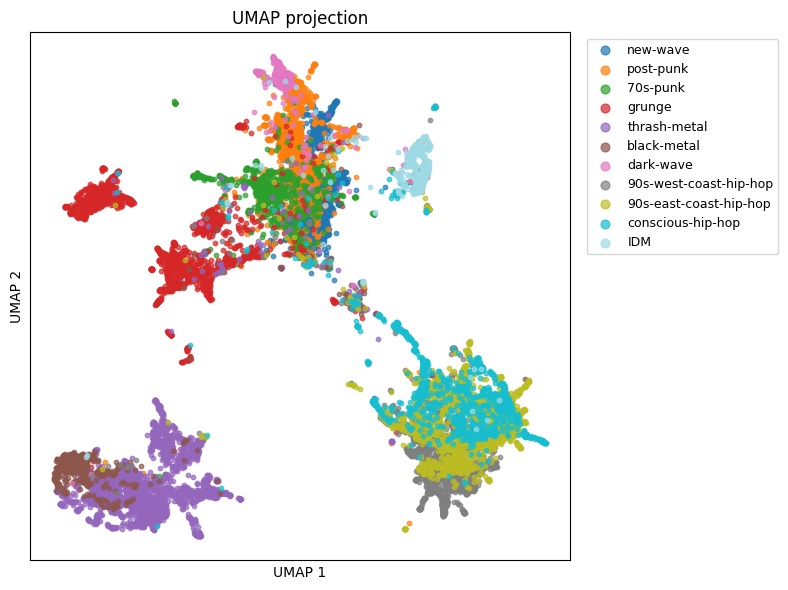

In [26]:
import matplotlib

fig, ax = plt.subplots(figsize=(8, 6))

genres = genre_df["genre"].unique()
cmap = plt.colormaps["tab20"].resampled(len(genres))

for i, genre in enumerate(genres):
    subset = genre_df[genre_df["genre"] == genre]
    ax.scatter(
        subset["umap_x"], subset["umap_y"],
        c=[cmap(i)], label=genre, s=10, alpha=0.7,
    )

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, markerscale=2)
ax.set_title("UMAP projection")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()